In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from pymorphy3 import MorphAnalyzer
import re

import requests
import time
import urllib
from zipfile import ZipFile
import shutil
import os

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.word2vec import Word2Vec
from gensim.models import KeyedVectors
from sentence_transformers import SentenceTransformer

from catboost import CatBoostClassifier
import torch
from transformers import pipeline
import optuna


# 1. Загрузка данных

Для решения задачи оценки здоровья бренда датасет был собран через API компании [Massive](https://massive.com/), которая предоставляет инструменты для работы с финансовыми данными.

В запросах к API был использован список тикеров крупнейших технологических компаний. Из получаемых json-файлов были извлечены следующие поля:

- `published_utc` - дата и время публикации;
- `title` - заголовок новости;
- `description` - краткое содержание новости, сгенерированное при помощи LLM;
- `publisher` - источник новости;
- `ticker` - тикер компании, для которой определена тональность;
- `sentiment` - тональность новости относительно указанной компании, распознанная при помощи LLM.

Поскольку одна новость может относиться сразу к нескольким компаниям, итоговый датасет был приведен к формату "новость - компания - тональность". Это позволяет учитывать, что одна и та же публикация может иметь разную тональность для разных брендов.

In [2]:
# API_KEY = os.getenv("MASSIVE_API_KEY")
# BASE_URL = "https://api.massive.com/v2/reference/news"

# tickers = {"AAPL", "MSFT", "GOOGL", "META", "AMZN", "NVDA", "NFLX", "ADBE", "INTC", "AMD", "IBM", "CSCO"}

# all_rows = []

# for t in tickers:
#     params = {"ticker": t, "limit": 1000, "apiKey": API_KEY, "sort": "published_utc", "order": "desc"}

#     response = requests.get(BASE_URL, params=params)
#     response.raise_for_status()

#     data = response.json()
#     articles = data.get("results", [])

#     for article in articles:
#         published_utc = article.get("published_utc")
#         title = article.get("title")
#         description = article.get("description")

#         publisher = article.get("publisher", {})
#         publisher_name = publisher.get("name")

#         insights = article.get("insights", [])

#         for insight in insights:
#             insight_ticker = insight.get("ticker")
#             sentiment = insight.get("sentiment")

#             if insight_ticker in tickers:
#                 all_rows.append({
#                     "published_utc": published_utc,
#                     "title": title,
#                     "description": description,
#                     "publisher": publisher_name,
#                     "ticker": insight_ticker,
#                     "sentiment": sentiment
#                 })

#     time.sleep(15)

In [3]:
# df = pd.DataFrame(all_rows)
# data = df.drop_duplicates(subset=["published_utc", "title", "description", "publisher", "ticker"])
# data.to_csv('data/dataset_massive.csv')

In [4]:
data = pd.read_csv('data/dataset_massive.csv')
data.head()

,Unnamed: 0,published_utc,title,description,publisher,ticker,sentiment
0,0,2026-06-03T20:26:39Z,The 'VOO And Chill' Economy Is Now Worth A His...,Vanguard's S&P 500 ETF (VOO) has become the fi...,Benzinga,AAPL,positive
1,1,2026-06-03T20:26:39Z,The 'VOO And Chill' Economy Is Now Worth A His...,Vanguard's S&P 500 ETF (VOO) has become the fi...,Benzinga,MSFT,positive
2,2,2026-06-03T20:26:39Z,The 'VOO And Chill' Economy Is Now Worth A His...,Vanguard's S&P 500 ETF (VOO) has become the fi...,Benzinga,NVDA,positive
3,3,2026-06-03T19:22:01Z,Broadcom's AI Revenue Doubled — And It May Not...,Broadcom reported $8.4 billion in AI semicondu...,Benzinga,META,positive
4,4,2026-06-03T19:22:01Z,Broadcom's AI Revenue Doubled — And It May Not...,Broadcom reported $8.4 billion in AI semicondu...,Benzinga,AAPL,positive


In [5]:
data.shape

(15022, 7)

В датасете чуть более 15 тысяч наблюдений.

In [6]:
data["sentiment"].value_counts()

sentiment
positive            7547
neutral             6049
negative            1415
mixed                  5
neutral/positive       4
neutral/negative       2
Name: count, dtype: int64

Из них: около половины - с лейблом "positive", около 6000 с тональностью "neutral", еще 1400 - с флагом "negative". Смешанные оценки удалены из датасета. 

In [7]:
data = data[data["sentiment"].isin(["positive", "neutral", "negative"])]
data["ticker"].value_counts()

ticker
NVDA     2673
GOOGL    1843
MSFT     1768
AMZN     1617
META     1243
AAPL     1181
AMD      1134
INTC     1023
NFLX      954
IBM       788
CSCO      402
ADBE      385
Name: count, dtype: int64

Самый популярный тикер в датасете - у компании Nvidia (2673 публикации с упоминанием), в то время как для компании Adobe было обнаружено только 385 новостей.

In [8]:
data.shape

(15011, 7)

In [9]:
data["datetime"] = pd.to_datetime(data["published_utc"], format="%Y-%m-%dT%H:%M:%SZ", errors="coerce", utc=True)

min_date = data['datetime'].dt.date.min()
max_date = data['datetime'].dt.date.max()

min_date, max_date

(datetime.date(2024, 7, 2), datetime.date(2026, 6, 3))

В датасете содержатся публикации со 2 июля 2024 года по 3 июня 2026 года.

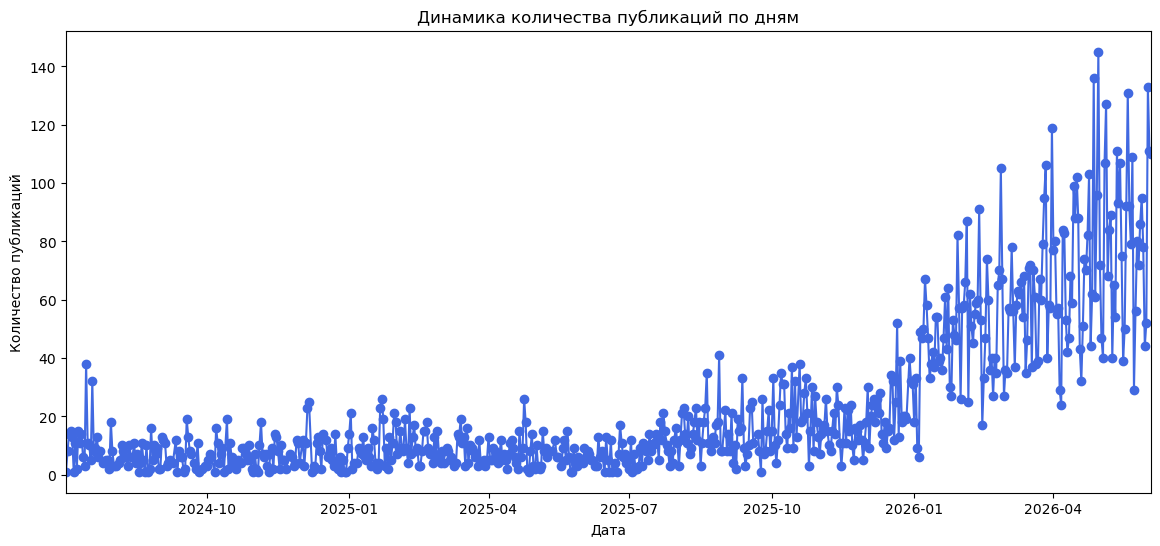

In [10]:
df = data.copy()
df["day"] = df["datetime"].dt.date
daily_counts = df.groupby("day").size()

plt.figure(figsize=(14, 6))
daily_counts.plot(kind="line", color="royalblue", marker="o")

plt.xlim(min_date, max_date)
plt.xlabel("Дата")
plt.ylabel("Количество публикаций")
plt.title("Динамика количества публикаций по дням")

plt.show()

Построив динамику количества публикаций, заметим, что с начала 2026 года их число значительно выше, чем в 2024 и 2025 годах. Это может быть связано не только с реальным ростом новостной активности вокруг выбранных компаний, но и с особенностями работы API Massive: например, с ограничениями глубины исторической выгрузки или полнотой хранения архивных новостей.

# 2. Классификация

Для анализа здоровья бренда все поступающие публикации должны быть отсортированы по тональности. Так как таргет принимает значения `{negative, neutral, positive}`, то мы будем работать с мультиклассовой классификацией. 

В рамках работы протестировано несколько подходов к обработке текстовых данных и получению эмбеддингов:
- CountVectorizer;
- TF-IDF;
- Word2Vec;
- предобученная модель Word2Vec;
- предобученная модель GloVe;
- Sentence Transformer.

Поверх полученных эмбеддингов применена базовая модель логистической регресии - `sklearn.linear_model.LogisticRegression`. Метрики, на основании которых делается вывод о качестве классификации, - макро `precision, recall, F1`.

 ## 2.1. Предобработка данных

Для преобработки данных проделаем следующие шаги:

- для каждого тикера добавим колонку с полным названием компании - `company_name`;

- объединим колонки заголовка и краткого описания новости в один признак `text`;
  
- значение тональности приведем к числовому виду, создав признак `target` = {-1, 0, 1};

- токенизируем текст с помощью функции `word_tokenize` из библиотеки `nltk`;

- очистим текст от символов, оставляя латиницу и числа, с помощью регулярных выражений;

- исключим стоп-слова для английского языка;

- лемматизируем слова через `MorphAnalyzer` в библиотеке `pymorphy3`.

In [11]:
data_preprocessed = data.copy()

company_names = {"AAPL": "Apple", "MSFT": "Microsoft", "GOOGL": "Google", "META": "Meta", "AMZN": "Amazon", "NVDA": "Nvidia", "NFLX": "Netflix", 
                 "ADBE": "Adobe", "INTC": "Intel", "AMD": "AMD", "IBM": "IBM", "CSCO": "Cisco"}
data_preprocessed["company_name"] = data_preprocessed["ticker"].map(company_names)

In [12]:
data_preprocessed['text'] = (data_preprocessed["title"] + ". " + data_preprocessed["description"])

In [13]:
data_preprocessed['target'] = data_preprocessed['sentiment'].map({'negative': -1, 'neutral': 0, 'positive': 1})

In [14]:
stopwords = stopwords.words('english')
en_words = re.compile("[a-zA-Z0-9]+")
lemmatizer = MorphAnalyzer()

def clean_text(texts):
    
    clean_dataset = []
    cache = {}  

    for text in texts: 
        lemmas = []
        
        for tok in word_tokenize(text.lower()):
            if not en_words.match(tok):
                continue
            if tok in stopwords:
                continue
            if tok not in cache:
                cache[tok] = lemmatizer.parse(tok)[0].normal_form
            lemmas.append(cache[tok])
            
        clean_dataset.append(lemmas)
        
    return [' '.join(w) for w in clean_dataset]

Так как одна и та же новость может встречаться в датасете несколько раз для разных тикеров, необходимо не допустить утечки данных между обучающей и тестовой выборками. Для этого создадим идентификатор новости: все строки, соответствующие одной публикации, получат одно и то же значение.

In [15]:
data_preprocessed["article_id"] = (data_preprocessed["datetime"].astype(str) + "_" + data_preprocessed["title"] + "_" + data_preprocessed["publisher"]).factorize()[0]

In [16]:
data_preprocessed = pd.DataFrame({"article_id": data_preprocessed['article_id'].values, "clean_text": clean_text(data_preprocessed['text'].values), 
                                  "text": data_preprocessed['text'].values, "company_name": data_preprocessed['company_name'].values, 
                                  "target": data_preprocessed['target'].values})
data_preprocessed.head()

,article_id,clean_text,text,company_name,target
0,0,chill economy worth historic 1 trillion vangua...,The 'VOO And Chill' Economy Is Now Worth A His...,Apple,1
1,0,chill economy worth historic 1 trillion vangua...,The 'VOO And Chill' Economy Is Now Worth A His...,Microsoft,1
2,0,chill economy worth historic 1 trillion vangua...,The 'VOO And Chill' Economy Is Now Worth A His...,Nvidia,1
3,1,broadcom ai revenue doubled may even halfway d...,Broadcom's AI Revenue Doubled — And It May Not...,Meta,1
4,1,broadcom ai revenue doubled may even halfway d...,Broadcom's AI Revenue Doubled — And It May Not...,Apple,1


Для разбиения данных на обучающую и тестовую выборки был использован `StratifiedGroupKFold`. В качестве групп выступал идентификатор новости `article_id`. Такой подход позволяет сохранить соотношение классов целевой переменной и одновременно не допустить утечки данных: все строки, соответствующие одной публикации, попадают только в одну из выборок.

In [17]:
X = data_preprocessed[["clean_text", "company_name"]]
y = data_preprocessed["target"]
groups = data_preprocessed["article_id"]

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))
train = data_preprocessed.iloc[train_idx].copy()
test = data_preprocessed.iloc[test_idx].copy()

X_train, X_test = train[["clean_text", "company_name"]], test[["clean_text", "company_name"]]
y_train, y_test = train['target'], test['target']

In [18]:
y_train.value_counts()

target
 1    5936
 0    4862
-1    1119
Name: count, dtype: int64

In [19]:
y_test.value_counts()

target
 1    1611
 0    1187
-1     296
Name: count, dtype: int64

Также зададим функцию для сохранения макро-метрик в единый датафрейм.

In [20]:
def get_metrics(algorithm, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    
    return {"algorithm": algorithm,
            "macro_precision": report["macro avg"]["precision"],
            "macro_recall": report["macro avg"]["recall"],
            "macro_f1": report["macro avg"]["f1-score"]}

## 2.2. Векторизация и эмбеддинги
### 2.2.1. CountVectorizer

В качестве базового способа представления текста был использован подход bag of words, реализованный с помощью `CountVectorizer`.

In [21]:
preprocessor_count_vec = ColumnTransformer(
    transformers=[("text", CountVectorizer(), "clean_text"),
                  ("company", OneHotEncoder(handle_unknown="ignore"), ["company_name"])]
)

In [22]:
lr_count_vec = Pipeline([
    ("preprocessor", preprocessor_count_vec),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

lr_count_vec.fit(X_train, y_train)
pred_count_vec = lr_count_vec.predict(X_test)
print(classification_report(y_test, pred_count_vec))

              precision    recall  f1-score   support

          -1       0.34      0.45      0.38       296
           0       0.52      0.49      0.50      1187
           1       0.65      0.64      0.64      1611

    accuracy                           0.56      3094
   macro avg       0.50      0.53      0.51      3094
weighted avg       0.57      0.56      0.57      3094



In [23]:
metrics = []
metrics.append(get_metrics('CountVectorizer', y_test, pred_count_vec))

### 2.2.2. TF-IDF

Вторым классическим способом векторизации текста был выбран метод `TF-IDF`. В отличие от CountVectorizer, который учитывает только абсолютные частоты слов в документе, TF-IDF дополнительно принимает во внимание распространеность слова во всем корпусе.

In [24]:
preprocessor_tfidf = ColumnTransformer(
    transformers=[("text", TfidfVectorizer(), "clean_text"),
                  ("company", OneHotEncoder(handle_unknown="ignore"), ["company_name"])]
)

In [25]:
lr_tfidf = Pipeline([
    ("preprocessor", preprocessor_tfidf),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

lr_tfidf.fit(X_train, y_train)
pred_tfidf = lr_tfidf.predict(X_test)
print(classification_report(y_test, pred_tfidf))

              precision    recall  f1-score   support

          -1       0.34      0.63      0.44       296
           0       0.55      0.56      0.55      1187
           1       0.72      0.60      0.65      1611

    accuracy                           0.59      3094
   macro avg       0.54      0.60      0.55      3094
weighted avg       0.62      0.59      0.59      3094



In [26]:
metrics.append(get_metrics('TfidfVectorizer', y_test, pred_tfidf))

### 2.2.3. Word2Vec (Skip-Gram)

Модель `Word2Vec` строит плотные векторные представления слов, отражающие их семантическую близость. В данной работе используется метод Skip-Gram, когда мы пытаемся предсказать контекст по переданному модели слову. Этот метод лучше работает с маленькими текстами и лучше представляет редкие слова.

In [27]:
X_train_w2vec = [text.split() for text in tqdm(X_train["clean_text"])]
X_test_w2vec = [text.split() for text in tqdm(X_test["clean_text"])]

100%|██████████| 3094/3094 [00:00<00:00, 454621.71it/s]


In [28]:
word_2vec = Word2Vec(X_train_w2vec, workers=1, vector_size=100, min_count=3, window=5, sg=1, epochs=15, seed=42)

In [29]:
def get_mean_word_embedding(text, model):
    model = model.wv if hasattr(model, "wv") else model
    vector_size = model.vector_size
    result = []

    for word in word_tokenize(text.lower()):
        if word in model:
            result.append(model[word])

    if len(result):
        result = np.mean(result, axis=0) 
    else:
        result = np.zeros(vector_size)
    return result

X_train_w2vec_text = [get_mean_word_embedding(text, word_2vec) for text in tqdm(X_train["clean_text"])]
X_test_w2vec_text = [get_mean_word_embedding(text, word_2vec) for text in tqdm(X_test["clean_text"])]

100%|██████████| 3094/3094 [00:00<00:00, 6853.25it/s]


In [30]:
ohe_company = OneHotEncoder(handle_unknown="ignore")

X_train_company = ohe_company.fit_transform(X_train[["company_name"]])
X_test_company = ohe_company.transform(X_test[["company_name"]])

In [31]:
X_train_w2vec_stacked = hstack([csr_matrix(X_train_w2vec_text), X_train_company])
X_test_w2vec_stacked = hstack([csr_matrix(X_test_w2vec_text), X_test_company])

In [32]:
lr_w2vec = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_w2vec.fit(X_train_w2vec_stacked, y_train)
pred_w2vec = lr_w2vec.predict(X_test_w2vec_stacked)
print(classification_report(y_test, pred_w2vec))

              precision    recall  f1-score   support

          -1       0.32      0.73      0.45       296
           0       0.53      0.53      0.53      1187
           1       0.70      0.54      0.61      1611

    accuracy                           0.56      3094
   macro avg       0.52      0.60      0.53      3094
weighted avg       0.60      0.56      0.57      3094



In [33]:
metrics.append(get_metrics('Word2Vec', y_test, pred_w2vec))

### 2.2.4. Word2Vec (Skip-Gram, pretrained)

Дополнительно были протестированы предобученные векторные представления слов.

В качестве источника был использован репозиторий [NLPL word embeddings repository](http://vectors.nlpl.eu/repository/). Для эксперимента была выбрана модель, обученная на корпусе [English Gigaword Fifth Edition](https://catalog.ldc.upenn.edu/LDC2011T07), поскольку данный корпус состоит из англоязычных новостных текстов и по домену близок к данным, используемым в работе.

In [34]:
# urllib.request.urlretrieve("https://vectors.nlpl.eu/repository/20/11.zip", "gigaword5_w2v.zip")

In [35]:
# if not os.path.exists("models"):
#     os.mkdir('models')

# with ZipFile('gigaword5_w2v.zip', 'r') as zf:
#     bin_file = [name for name in zf.namelist() if name.endswith(".bin")][0]
#     with zf.open(bin_file) as source, open("models/gigaword_w2v.bin", "wb") as target:
#         shutil.copyfileobj(source, target)

In [36]:
word_2vec_pretr = KeyedVectors.load_word2vec_format('models/gigaword_w2v.bin', binary=True)
X_train_w2vec_pretr_text = [get_mean_word_embedding(text, word_2vec_pretr) for text in tqdm(X_train["clean_text"])]
X_test_w2vec_pretr_text = [get_mean_word_embedding(text, word_2vec_pretr) for text in tqdm(X_test["clean_text"])]

100%|██████████| 3094/3094 [00:00<00:00, 6610.17it/s]


In [37]:
X_train_w2vec_pretr_stacked = hstack([csr_matrix(X_train_w2vec_pretr_text), X_train_company])
X_test_w2vec_pretr_stacked = hstack([csr_matrix(X_test_w2vec_pretr_text), X_test_company])

In [38]:
lr_w2vec_pretr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_w2vec_pretr.fit(X_train_w2vec_pretr_stacked, y_train)
pred_w2vec_pretr = lr_w2vec_pretr.predict(X_test_w2vec_pretr_stacked)
print(classification_report(y_test, pred_w2vec_pretr))

              precision    recall  f1-score   support

          -1       0.27      0.68      0.38       296
           0       0.52      0.53      0.53      1187
           1       0.70      0.49      0.58      1611

    accuracy                           0.53      3094
   macro avg       0.50      0.57      0.50      3094
weighted avg       0.59      0.53      0.54      3094



In [39]:
metrics.append(get_metrics('Word2Vec (pretrained)', y_test, pred_w2vec_pretr))

### 2.2.5. GloVe (pretrained)

Дополнительно были протестированы предобученные эмбеддинги `GloVe`. Если Word2Vec обучается на задаче предсказания контекстных слов, то GloVe строит векторные представления на основе глобальной статистики совместной встречаемости слов в корпусе.

Предобученная модель GloVe взята из репозитория [NLPL word embeddings repository](http://vectors.nlpl.eu/repository/). Модель также обучена на корпусе [English Gigaword Fifth Edition](https://catalog.ldc.upenn.edu/LDC2011T07).

In [40]:
# urllib.request.urlretrieve("https://vectors.nlpl.eu/repository/20/14.zip", "gigaword5_glove.zip")

In [41]:
# with ZipFile('gigaword5_glove.zip', 'r') as zf:
#     bin_file = [name for name in zf.namelist() if name.endswith(".bin")][0]
#     with zf.open(bin_file) as source, open("models/gigaword_glove.bin", "wb") as target:
#         shutil.copyfileobj(source, target)

In [42]:
glove_pretr = KeyedVectors.load_word2vec_format('models/gigaword_glove.bin', binary=True)
X_train_glove_pretr_text = [get_mean_word_embedding(text, glove_pretr) for text in tqdm(X_train["clean_text"])]
X_test_glove_pretr_text = [get_mean_word_embedding(text, glove_pretr) for text in tqdm(X_test["clean_text"])]

100%|██████████| 3094/3094 [00:00<00:00, 6368.44it/s]


In [43]:
X_train_glove_pretr_stacked = hstack([csr_matrix(X_train_glove_pretr_text), X_train_company])
X_test_glove_pretr_stacked = hstack([csr_matrix(X_test_glove_pretr_text), X_test_company])

In [44]:
lr_glove_pretr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_glove_pretr.fit(X_train_glove_pretr_stacked, y_train)
pred_glove_pretr = lr_glove_pretr.predict(X_test_glove_pretr_stacked)
print(classification_report(y_test, pred_glove_pretr))

              precision    recall  f1-score   support

          -1       0.30      0.72      0.42       296
           0       0.53      0.54      0.53      1187
           1       0.71      0.51      0.60      1611

    accuracy                           0.54      3094
   macro avg       0.51      0.59      0.52      3094
weighted avg       0.60      0.54      0.55      3094



In [45]:
metrics.append(get_metrics('GloVe (pretrained)', y_test, pred_glove_pretr))

### 2.2.6. Sentence Transformers

В качестве современного подхода к построению контекстных представлений текста была использована модель, обученная на задаче `sentence-transformers`: `mukaj/fin-mpnet-base`. Как отмечается в карточке модели, она показывает высокое качество на задачах, связанных с извлечением информации из финансовых документов.

Так как трансформер обучался на корпусе естественных текстов, мы будем тестировать модель на оригинальном тексте новости, а не очищенном.

In [46]:
X_train_ori, X_test_ori = train['text'], test['text']

sent_transformer = SentenceTransformer("mukaj/fin-mpnet-base")
X_train_sentran_text = sent_transformer.encode(X_train_ori.astype(str).tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)
X_test_sentran_text = sent_transformer.encode(X_test_ori.astype(str).tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/373 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

In [47]:
X_train_sentran_stacked = hstack([csr_matrix(X_train_sentran_text), X_train_company])
X_test_sentran_stacked = hstack([csr_matrix(X_test_sentran_text), X_test_company])

In [49]:
lr_sentran = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_sentran.fit(X_train_sentran_stacked, y_train)
pred_sentran = lr_sentran.predict(X_test_sentran_stacked)
print(classification_report(y_test, pred_sentran))

              precision    recall  f1-score   support

          -1       0.32      0.72      0.44       296
           0       0.54      0.54      0.54      1187
           1       0.72      0.55      0.62      1611

    accuracy                           0.56      3094
   macro avg       0.52      0.60      0.53      3094
weighted avg       0.61      0.56      0.57      3094



In [50]:
metrics.append(get_metrics('Sentence Transformer', y_test, pred_sentran))

### 2.2.7. Обсуждение полученных результатов

Для каждого из рассмотренных способов векторизации и подготовки эмбеддингов использовалась логистическая регрессия с единым набором параметров. Такой подход позволяет сравнить именно способы представления текста, минимизируя влияние выбора классификатора. Оценка качества проводилась по макро-метрикам precision, recall и F1, т.к. классы в задаче несбалансированы.

Полученные результаты показывают, что наилучшее значение макро F1 было достигнуто при использовании TF-IDF, при этом по макро recall (полноте) лидирует Sentence Transformer и Word2Vec.

In [51]:
pd.DataFrame(metrics).sort_values(by='macro_f1', ascending=False, ignore_index=True)

,algorithm,macro_precision,macro_recall,macro_f1
0,TfidfVectorizer,0.536649,0.595253,0.550198
1,Sentence Transformer,0.523163,0.601033,0.532368
2,Word2Vec,0.519632,0.601089,0.530529
3,GloVe (pretrained),0.511099,0.590501,0.515419
4,CountVectorizer,0.502626,0.525219,0.511342
5,Word2Vec (pretrained),0.497055,0.567124,0.496085


## 2.3. Сравнение классификаторов

По результатам предыдущего этапа для дальнейшего сравнения были выбраны два наиболее эффективных способа представления текста по метрике macro F1: `TfidfVectorizer` и `Sentence Transformer`. Далее для каждого из выбранных признаковых представлений были протестированы различные алгоритмы классификации.

Выбор моделей был основан на работах по анализу тональности в текстах. Подходы Naive Bayes и SVM часто используются как бейзлайн-методы для текстовой классификации <sup>1</sup>. Также в исследования применяются такие алгоритмы, как Logistic Regression и KNN <sup>2</sup>.

- `TfidfVectorizer`. При применении этого способа векторизации мы работаем с разреженной матрицей. Поэтому рассмотрены следующие алгоритмы классификации:

1) Logistic Regression;
2) Naive Bayes;
3) Support Vector Machine.

- `Sentence Transformer`. Для эмбеддингов Sentence Transformer были рассмотрены классификаторы, работающие с плотными числовыми признаками:

1) Logistic Regression;
2) K-Nearest Neighbors;
3) Gradient Boosting.

- ансамбль `TfidfVectorizer` и `Sentence Transformer` для гибридного текстового представления. Классификаторы: 

1) Logistic Regression;
2) SVM.

- `FinBERT sentiment model` как полноценный классификатор. 


<sup>1</sup> Wang, S., Manning, C.D. (2012). Baselines and bigrams: Simple, good sentiment and topic classification. In Proceedings of the 50th Annual Meeting of the Association for Computational Linguistics. URL: https://aclanthology.org/P12-2018/

<sup>2</sup> Ul Hassan, S., Ahamed, J., Ahmad, K. (2022). Analytics of machine learning-based algorithms for text classification. Sustainable Operations and Computers. URL: https://doi.org/10.1016/j.susoc.2022.03.001

### 2.3.1. TF-IDF + Logistic Regression

In [52]:
preprocessor_tfidf = ColumnTransformer(
    transformers=[("text", TfidfVectorizer(), "clean_text"),
                  ("company", OneHotEncoder(handle_unknown="ignore"), ["company_name"])]
)

lr_tfidf = Pipeline([
    ("preprocessor", preprocessor_tfidf),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

lr_tfidf.fit(X_train, y_train)
pred_lr_tfidf = lr_tfidf.predict(X_test)
print(classification_report(y_test, pred_lr_tfidf))

              precision    recall  f1-score   support

          -1       0.34      0.63      0.44       296
           0       0.55      0.56      0.55      1187
           1       0.72      0.60      0.65      1611

    accuracy                           0.59      3094
   macro avg       0.54      0.60      0.55      3094
weighted avg       0.62      0.59      0.59      3094



In [53]:
classification_metrics = []
classification_metrics.append(get_metrics('TF-IDF (Logistic Regression)', y_test, pred_lr_tfidf))

### 2.3.2. TF-IDF + Naive Bayes

In [ ]:
nb_tfidf = Pipeline([("preprocessor", preprocessor_tfidf),
                     ("classifier", ComplementNB())
])

nb_tfidf.fit(X_train, y_train)
pred_nb_tfidf = nb_tfidf.predict(X_test)
print(classification_report(y_test, pred_nb_tfidf))

              precision    recall  f1-score   support

          -1       0.35      0.41      0.38       296
           0       0.51      0.53      0.52      1187
           1       0.67      0.62      0.65      1611

    accuracy                           0.57      3094
   macro avg       0.51      0.52      0.51      3094
weighted avg       0.58      0.57      0.57      3094



In [55]:
classification_metrics.append(get_metrics('TF-IDF (Naive Bayes)', y_test, pred_nb_tfidf))

### 2.3.3. TF-IDF + Support Vector Machine

In [ ]:
svm_tfidf = Pipeline([("preprocessor", preprocessor_tfidf),
                      ("classifier", LinearSVC(class_weight="balanced", random_state=42))
])

svm_tfidf.fit(X_train, y_train)
pred_svm_tfidf = svm_tfidf.predict(X_test)
print(classification_report(y_test, pred_svm_tfidf))

              precision    recall  f1-score   support

          -1       0.35      0.43      0.39       296
           0       0.54      0.50      0.52      1187
           1       0.67      0.67      0.67      1611

    accuracy                           0.58      3094
   macro avg       0.52      0.53      0.53      3094
weighted avg       0.59      0.58      0.58      3094



In [57]:
classification_metrics.append(get_metrics('TF-IDF (SVM)', y_test, pred_svm_tfidf))

### 2.3.4. Sentence Transformer + Logistic Regression

In [59]:
lr_sentran = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_sentran.fit(X_train_sentran_stacked, y_train)
pred_lr_sentran = lr_sentran.predict(X_test_sentran_stacked)
print(classification_report(y_test, pred_lr_sentran))

              precision    recall  f1-score   support

          -1       0.32      0.72      0.44       296
           0       0.54      0.54      0.54      1187
           1       0.72      0.55      0.62      1611

    accuracy                           0.56      3094
   macro avg       0.52      0.60      0.53      3094
weighted avg       0.61      0.56      0.57      3094



In [61]:
classification_metrics.append(get_metrics('Sentence Transformer (Logistic Regression)', y_test, pred_lr_sentran))

### 2.3.5. Sentence Transformer + KNN

In [ ]:
knn_sentran = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn_sentran.fit(X_train_sentran_stacked, y_train)
pred_knn_sentran = knn_sentran.predict(X_test_sentran_stacked)
print(classification_report(y_test, pred_knn_sentran))

              precision    recall  f1-score   support

          -1       0.45      0.45      0.45       296
           0       0.59      0.55      0.57      1187
           1       0.70      0.74      0.72      1611

    accuracy                           0.64      3094
   macro avg       0.58      0.58      0.58      3094
weighted avg       0.64      0.64      0.64      3094



In [64]:
classification_metrics.append(get_metrics('Sentence Transformer (KNN)', y_test, pred_knn_sentran))

### 2.3.6. Sentence Transformer + Gradient Boosting

In [ ]:
cat_sentran = CatBoostClassifier(iterations=500, loss_function="MultiClass", random_seed=42, verbose=0)
cat_sentran.fit(X_train_sentran_stacked, y_train)
pred_cat_sentran = cat_sentran.predict(X_test_sentran_stacked)
print(classification_report(y_test, pred_cat_sentran))

              precision    recall  f1-score   support

          -1       0.61      0.34      0.44       296
           0       0.59      0.62      0.61      1187
           1       0.71      0.74      0.73      1611

    accuracy                           0.66      3094
   macro avg       0.64      0.57      0.59      3094
weighted avg       0.66      0.66      0.65      3094



In [66]:
classification_metrics.append(get_metrics('Sentence Transformer (CatBoost)', y_test, pred_cat_sentran))

### 2.3.7. Ансамбль TF-IDF и Sentence Transformer + Logistic Regression

In [67]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train['clean_text'])
X_test_tfidf = tfidf.transform(X_test['clean_text'])

X_train_sentran_sparse = csr_matrix(X_train_sentran_text)
X_test_sentran_sparse = csr_matrix(X_test_sentran_text)

X_train_ensemble = hstack([X_train_tfidf, X_train_sentran_sparse, X_train_company])
X_test_ensemble = hstack([X_test_tfidf, X_test_sentran_sparse, X_test_company])

In [68]:
lr_ensemble = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
lr_ensemble.fit(X_train_ensemble, y_train)
pred_lr_ensemble = lr_ensemble.predict(X_test_ensemble)
print(classification_report(y_test, pred_lr_ensemble))

              precision    recall  f1-score   support

          -1       0.38      0.70      0.49       296
           0       0.56      0.55      0.55      1187
           1       0.72      0.62      0.67      1611

    accuracy                           0.60      3094
   macro avg       0.55      0.62      0.57      3094
weighted avg       0.63      0.60      0.61      3094



In [69]:
classification_metrics.append(get_metrics('Ensemble (Logistic Regression)', y_test, pred_lr_ensemble))

### 2.3.8. Ансамбль TF-IDF и Sentence Transformer + SVM

In [70]:
svm_ensemble = LinearSVC(class_weight="balanced", random_state=42)
svm_ensemble.fit(X_train_ensemble, y_train)
pred_svm_ensemble = svm_ensemble.predict(X_test_ensemble)
print(classification_report(y_test, pred_svm_ensemble))

              precision    recall  f1-score   support

          -1       0.41      0.51      0.45       296
           0       0.54      0.53      0.54      1187
           1       0.67      0.65      0.66      1611

    accuracy                           0.59      3094
   macro avg       0.54      0.56      0.55      3094
weighted avg       0.60      0.59      0.59      3094



In [71]:
classification_metrics.append(get_metrics('Ensemble (SVM)', y_test, pred_svm_ensemble))

### 2.3.9. FinBERT

FinBERT "из коробки" определяет общую тональность текста. Для того чтобы тональность определялась относительно компании, добавим ее название в начале новости.

Поскольку FinBERT использовался как готовая предобученная модель, он не дообучался на train. Однако для сопоставимости результатов качество FinBERT оценивалось на той же тестовой выборке, что и качество предыдущих моделей.

In [72]:
X_test_finbert = test[['text', 'company_name']].copy()
X_test_finbert['text_company'] = "Company: " + test['company_name'] + '. ' + test['text']
X_test_finbert_text = X_test_finbert['text_company'].astype(str).tolist()

In [ ]:
device = 0 if torch.cuda.is_available() else -1
finbert = pipeline(task="text-classification", model="ProsusAI/finbert", tokenizer="ProsusAI/finbert", device=device)
preds = finbert(X_test_finbert_text, batch_size=16, truncation=True, max_length=512)
label_to_target = {"negative": -1, "neutral": 0, "positive": 1}
pred_finbert = [label_to_target[p["label"].lower()] for p in preds]
print(classification_report(y_test, pred_finbert))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

              precision    recall  f1-score   support

          -1       0.25      0.70      0.37       296
           0       0.36      0.15      0.21      1187
           1       0.58      0.65      0.61      1611

    accuracy                           0.46      3094
   macro avg       0.40      0.50      0.40      3094
weighted avg       0.47      0.46      0.44      3094



In [74]:
classification_metrics.append(get_metrics('FinBERT', y_test, pred_finbert))

### 2.3.10. Обсуждение результатов классификации

Предобученная модель FinBERT показала наихудший результат классификации. Это может быть связано с тем, что модель определяет общую финансовую тональность текста, тогда как в данной работе задача формулируется как определение тональности новости относительно конкретного тикера. Добавление названия компании в начало текста также не привело к улучшению результата, что может объясняться тем, что FinBERT не обучался на таком формате входных данных.

Лучшей по метрикам macro F1 и macro precision оказалась модель CatBoost, натренированная на эмбеддингах Sentence Transformer: значение F1 равно 0.5909, precision равен 0.6380. Второй результат показала модель KNN, также обученная на эмбеддингах Sentence Transformer. Кроме того, на фоне проведенных измерений выделяется логистическая регрессия, обучающаяся на гибридном признаковом пространстве и получившая macro recall, равный 0.6215.

In [75]:
pd.DataFrame(classification_metrics).sort_values(by='macro_f1', ascending=False, ignore_index=True)

,algorithm,macro_precision,macro_recall,macro_f1
0,Sentence Transformer (CatBoost),0.638038,0.569277,0.590893
1,Sentence Transformer (KNN),0.580765,0.578337,0.579179
2,Ensemble (Logistic Regression),0.552682,0.621485,0.570059
3,Ensemble (SVM),0.542168,0.564422,0.551521
4,TF-IDF (Logistic Regression),0.536649,0.595253,0.550198
5,Sentence Transformer (Logistic Regression),0.523163,0.601033,0.532368
6,TF-IDF (SVM),0.518307,0.534784,0.525033
7,TF-IDF (Naive Bayes),0.507067,0.521555,0.512961
8,FinBERT,0.400512,0.498544,0.400169


Далее будет работать с тремя моделями классификации, показавшими максимальное значение macro F1.

На первом этапе запустим поиск оптимального значения гиперпараметров для каждой модели. На втором этапе объединим предсказания моделей в ансамбль.

### 2.3.11. Подбор гиперпараметров

Так как для подбора оптимальных параметров модели нам нужна валидационная выборка, разделим исходный датафрейм на три составляющие: train, test, val.

In [76]:
X = data_preprocessed[["clean_text", "text", "company_name"]]
y = data_preprocessed["target"]
groups_full = data_preprocessed["article_id"]

splitter_full = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx_full, test_idx = next(splitter_full.split(X, y, groups=groups_full))

train_full = data_preprocessed.iloc[train_idx_full].copy()
test = data_preprocessed.iloc[test_idx].copy()

X_train_full, X_test = train_full[["clean_text", "text", "company_name"]], test[["clean_text", "text", "company_name"]]
y_train_full, y_test = train_full["target"], test["target"]

In [77]:
groups = train_full["article_id"]

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(splitter.split(X_train_full, y_train_full, groups=groups))

train = train_full.iloc[train_idx].copy()
val = train_full.iloc[val_idx].copy()

X_train, X_val = train[["clean_text", "text", "company_name"]], val[["clean_text", "text", "company_name"]]
y_train, y_val = train["target"], val["target"]

Sentence Transformer (CatBoost) - поиск гиперпараметров

In [78]:
X_train_company = ohe_company.fit_transform(X_train[["company_name"]])
X_val_company = ohe_company.transform(X_val[["company_name"]])

X_train_sentran_text = sent_transformer.encode(X_train["text"].astype(str).tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)
X_val_sentran_text = sent_transformer.encode(X_val["text"].astype(str).tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)

X_train_sentran_stacked = hstack([csr_matrix(X_train_sentran_text), X_train_company])
X_val_sentran_stacked = hstack([csr_matrix(X_val_sentran_text), X_val_company])

Batches:   0%|          | 0/295 [00:00<?, ?it/s]

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

In [ ]:
def objective(trial):

    param = {
        "loss_function": "MultiClass",
        "eval_metric": "TotalF1",
        "iterations": trial.suggest_int("iterations", 200, 1000),
        "learning_rate":  trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "class_weight_option": trial.suggest_categorical("class_weight_option", ["none", "balanced", "sqrt_balanced", "neg_2", "neg_3", "neg_4", "neg_5"]),
        "random_seed": 42,
        "task_type": "GPU",
        "devices": "0"

    }

    class_weight_option = param.pop("class_weight_option")
    
    if class_weight_option == "balanced":
        param["auto_class_weights"] = "Balanced"
    elif class_weight_option == "sqrt_balanced":
        param["auto_class_weights"] = "SqrtBalanced"
    elif class_weight_option == "neg_2":
        param["class_weights"] = {-1: 2, 0: 1, 1: 1}
    elif class_weight_option == "neg_3":
        param["class_weights"] = {-1: 3, 0: 1, 1: 1}
    elif class_weight_option == "neg_4":
        param["class_weights"] = {-1: 4, 0: 1, 1: 1}
    elif class_weight_option == "neg_5":
        param["class_weights"] = {-1: 5, 0: 1, 1: 1}

    model = CatBoostClassifier(**param)
    model.fit(X_train_sentran_stacked, y_train, eval_set=[(X_val_sentran_stacked, y_val)], verbose=0, early_stopping_rounds=100)
    preds = model.predict(X_val_sentran_stacked)
    f1 = f1_score(y_val, preds, average="macro")

    return f1

study = optuna.create_study(direction='maximize') 
study.optimize(objective, n_trials=30)

print("Best trial score:", study.best_value)
print("Best hyperparameters:", study.best_params)

[I 2026-06-30 00:24:01,823] A new study created in memory with name: no-name-33a02d45-8760-4ebf-a235-10e571f30ab3
[I 2026-06-30 00:24:06,950] Trial 0 finished with value: 0.5322586766400154 and parameters: {'iterations': 366, 'learning_rate': 0.05082660647872898, 'depth': 5, 'l2_leaf_reg': 0.713172369317713, 'bagging_temperature': 3.4005923843456514, 'class_weight_option': 'balanced'}. Best is trial 0 with value: 0.5322586766400154.
[I 2026-06-30 00:24:09,160] Trial 1 finished with value: 0.4909538238308837 and parameters: {'iterations': 284, 'learning_rate': 0.010126164554890323, 'depth': 5, 'l2_leaf_reg': 0.44649494773172044, 'bagging_temperature': 2.4494644825285814, 'class_weight_option': 'neg_2'}. Best is trial 0 with value: 0.5322586766400154.
[I 2026-06-30 00:24:10,373] Trial 2 finished with value: 0.4013742937973805 and parameters: {'iterations': 627, 'learning_rate': 0.010723569354778263, 'depth': 3, 'l2_leaf_reg': 0.5489986685413246, 'bagging_temperature': 4.265879964496474, 

Best trial score: 0.5825651657436507
Best hyperparameters: {'iterations': 534, 'learning_rate': 0.08842459522869721, 'depth': 7, 'l2_leaf_reg': 9.371485582972626, 'bagging_temperature': 1.4509350729845583, 'class_weight_option': 'sqrt_balanced'}


In [95]:
best_params_catboost = study.best_params.copy()

class_weight_option = best_params_catboost.pop("class_weight_option")

best_params_catboost.update({
    "loss_function": "MultiClass",
    "eval_metric": "TotalF1",
    "random_seed": 42,
    "task_type": "GPU",
    "devices": "0",
    "verbose": 0
})

if class_weight_option == "balanced":
    best_params_catboost["auto_class_weights"] = "Balanced"
elif class_weight_option == "sqrt_balanced":
    best_params_catboost["auto_class_weights"] = "SqrtBalanced"
elif class_weight_option == "neg_2":
    best_params_catboost["class_weights"] = {-1: 2, 0: 1, 1: 1}
elif class_weight_option == "neg_3":
    best_params_catboost["class_weights"] = {-1: 3, 0: 1, 1: 1}
elif class_weight_option == "neg_4":
    best_params_catboost["class_weights"] = {-1: 4, 0: 1, 1: 1}
elif class_weight_option == "neg_5":
    best_params_catboost["class_weights"] = {-1: 5, 0: 1, 1: 1}

best_catboost = CatBoostClassifier(**best_params_catboost)

best_catboost.fit(
    X_train_sentran_stacked,
    y_train,
    eval_set=[(X_val_sentran_stacked, y_val)],
    early_stopping_rounds=100,
    verbose=0
)

X_test_company = ohe_company.transform(X_test[["company_name"]])
X_test_sentran_text = sent_transformer.encode(X_test["text"].astype(str).tolist(), batch_size=32, show_progress_bar=True, convert_to_numpy=True)
X_test_sentran_stacked = hstack([csr_matrix(X_test_sentran_text), X_test_company])

pred_test = best_catboost.predict(X_test_sentran_stacked)

print(classification_report(y_test, pred_test))

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

              precision    recall  f1-score   support

          -1       0.52      0.49      0.51       296
           0       0.59      0.60      0.60      1187
           1       0.71      0.71      0.71      1611

    accuracy                           0.65      3094
   macro avg       0.61      0.60      0.60      3094
weighted avg       0.65      0.65      0.65      3094



Sentence Transformer (KNN) - подбор гиперпараметров

In [113]:
def objective(trial):
    knn_param = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 51, step=2),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": trial.suggest_categorical("metric", ["cosine", "euclidean", "manhattan"]),
        "n_jobs": -1
    }

    knn = KNeighborsClassifier(**knn_param)

    knn.fit(X_train_sentran_stacked, y_train)

    preds = knn.predict(X_val_sentran_stacked)
    f1 = f1_score(y_val, preds, average="macro")

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best trial score:", study.best_value)
print("Best hyperparameters:", study.best_params)

[I 2026-06-30 03:01:05,679] A new study created in memory with name: no-name-dcc54f4d-04d9-4446-aa22-52772b0c4186
[I 2026-06-30 03:01:07,326] Trial 0 finished with value: 0.5462138582768216 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 0 with value: 0.5462138582768216.
[I 2026-06-30 03:01:08,443] Trial 1 finished with value: 0.5060767501160207 and parameters: {'n_neighbors': 21, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 0 with value: 0.5462138582768216.
[I 2026-06-30 03:01:09,601] Trial 2 finished with value: 0.5253302938710275 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: 0.5462138582768216.
[I 2026-06-30 03:01:11,252] Trial 3 finished with value: 0.44754118433216217 and parameters: {'n_neighbors': 49, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.5462138582768216.
[I 2026-06-30 03:01:12,810] Trial 4 finished with value: 0.514

Best trial score: 0.5518143913423343
Best hyperparameters: {'n_neighbors': 5, 'weights': 'distance', 'metric': 'cosine'}


In [114]:
best_params_knn = study.best_params.copy()

best_knn = KNeighborsClassifier(**best_params_knn, n_jobs=-1)
best_knn.fit(X_train_sentran_stacked, y_train)
pred_test = best_knn.predict(X_test_sentran_stacked)

print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

          -1       0.53      0.42      0.47       296
           0       0.61      0.55      0.58      1187
           1       0.69      0.76      0.72      1611

    accuracy                           0.65      3094
   macro avg       0.61      0.58      0.59      3094
weighted avg       0.64      0.65      0.64      3094



Ensemble (Logistic Regression) - поиск гиперпараметров

In [98]:
X_train_sentran_sparse = csr_matrix(X_train_sentran_text)
X_val_sentran_sparse = csr_matrix(X_val_sentran_text)

In [110]:
def objective(trial):

    tfidf_param = {
        "ngram_range": (1, trial.suggest_int("ngram_max", 1, 2)),
        "max_features": trial.suggest_categorical("max_features", [10000, 20000, 50000, 100000]),
        "min_df": trial.suggest_categorical("min_df", [1, 2, 3, 5]),
        "max_df": trial.suggest_float("max_df", 0.7, 1.0),
        "sublinear_tf": trial.suggest_categorical("sublinear_tf", [True, False]),
        "norm": trial.suggest_categorical("norm", ["l1", "l2", None])
    }

    solver = trial.suggest_categorical("solver", ["lbfgs", "saga"])
    
    lr_param = {
        "C": trial.suggest_float("C", 0.01, 5.0, log=True),
        "class_weight_option": trial.suggest_categorical("class_weight_option", ["none", "balanced", "neg_2", "neg_3", "neg_4", "neg_5"]),
        "penalty": "l2",
        "max_iter": 10000,
        "solver": solver,
        "random_state": 42
    }

    if solver == "saga":
        lr_param["n_jobs"] = -1

    class_weight_option = lr_param.pop("class_weight_option")

    if class_weight_option == "none":
        lr_param["class_weight"] = None
    elif class_weight_option == "balanced":
        lr_param["class_weight"] = "balanced"
    elif class_weight_option == "neg_2":
        lr_param["class_weight"] = {-1: 2, 0: 1, 1: 1}
    elif class_weight_option == "neg_3":
        lr_param["class_weight"] = {-1: 3, 0: 1, 1: 1}
    elif class_weight_option == "neg_4":
        lr_param["class_weight"] = {-1: 4, 0: 1, 1: 1}
    elif class_weight_option == "neg_5":
        lr_param["class_weight"] = {-1: 5, 0: 1, 1: 1}

    tfidf = TfidfVectorizer(**tfidf_param)

    X_train_tfidf = tfidf.fit_transform(X_train["clean_text"])
    X_val_tfidf = tfidf.transform(X_val["clean_text"])

    X_train_ensemble = hstack([X_train_tfidf, X_train_sentran_sparse, X_train_company])
    X_val_ensemble = hstack([X_val_tfidf, X_val_sentran_sparse, X_val_company])

    model = LogisticRegression(**lr_param)

    model.fit(X_train_ensemble, y_train)

    preds = model.predict(X_val_ensemble)
    f1 = f1_score(y_val, preds, average="macro")

    return f1

study = optuna.create_study(direction='maximize') 
study.optimize(objective, n_trials=30)

print("Best trial score:", study.best_value)
print("Best hyperparameters:", study.best_params)

[I 2026-06-30 02:08:44,879] A new study created in memory with name: no-name-34a439c5-d25e-4843-9a9f-ccd785209c00
[I 2026-06-30 02:08:47,833] Trial 0 finished with value: 0.5582093015460589 and parameters: {'ngram_max': 1, 'max_features': 20000, 'min_df': 3, 'max_df': 0.7942018495740839, 'sublinear_tf': True, 'norm': 'l2', 'solver_l2': 'lbfgs', 'C_l2': 1.4932123227982796, 'class_weight_option': 'balanced'}. Best is trial 0 with value: 0.5582093015460589.
[I 2026-06-30 02:08:59,317] Trial 1 finished with value: 0.521924363624855 and parameters: {'ngram_max': 2, 'max_features': 50000, 'min_df': 3, 'max_df': 0.8665221235639464, 'sublinear_tf': True, 'norm': None, 'solver_l2': 'lbfgs', 'C_l2': 1.9429472624072937, 'class_weight_option': 'balanced'}. Best is trial 0 with value: 0.5582093015460589.
[I 2026-06-30 02:09:00,716] Trial 2 finished with value: 0.46004513023428945 and parameters: {'ngram_max': 2, 'max_features': 50000, 'min_df': 1, 'max_df': 0.9401791319376174, 'sublinear_tf': True,

Best trial score: 0.5660867657303134
Best hyperparameters: {'ngram_max': 1, 'max_features': 100000, 'min_df': 3, 'max_df': 0.7928583132005051, 'sublinear_tf': False, 'norm': 'l2', 'solver_l2': 'saga', 'C_l2': 2.442236998137998, 'class_weight_option': 'neg_2'}


In [ ]:
best_params_ensemble = study.best_params.copy()

tfidf_best = TfidfVectorizer(
    ngram_range=(1, best_params_ensemble["ngram_max"]),
    max_features=best_params_ensemble["max_features"],
    min_df=best_params_ensemble["min_df"],
    max_df=best_params_ensemble["max_df"],
    sublinear_tf=best_params_ensemble["sublinear_tf"],
    norm=best_params_ensemble["norm"]
)

X_train_tfidf = tfidf_best.fit_transform(X_train["clean_text"])
X_val_tfidf = tfidf_best.transform(X_val["clean_text"])
X_test_tfidf = tfidf_best.transform(X_test["clean_text"])

X_test_sentran_sparse = csr_matrix(X_test_sentran_text)

X_train_ensemble = hstack([X_train_tfidf, X_train_sentran_sparse, X_train_company])
X_val_ensemble = hstack([X_val_tfidf, X_val_sentran_sparse, X_val_company])
X_test_ensemble = hstack([X_test_tfidf, X_test_sentran_sparse, X_test_company])

class_weight_option = best_params_ensemble["class_weight_option"]

if class_weight_option == "none":
    best_class_weight = None
elif class_weight_option == "balanced":
    best_class_weight = "balanced"
elif class_weight_option == "neg_2":
    best_class_weight = {-1: 2, 0: 1, 1: 1}
elif class_weight_option == "neg_3":
    best_class_weight = {-1: 3, 0: 1, 1: 1}
elif class_weight_option == "neg_4":
    best_class_weight = {-1: 4, 0: 1, 1: 1}
elif class_weight_option == "neg_5":
    best_class_weight = {-1: 5, 0: 1, 1: 1}

best_ensemble_lr = LogisticRegression(
    C=best_params_ensemble["C"],
    class_weight=best_class_weight,
    penalty="l2",
    solver=best_params_ensemble["solver"],
    max_iter=5000,
    random_state=42,
    n_jobs=-1 if best_params_ensemble["solver"] == "saga" else None
)

best_ensemble_lr.fit(X_train_ensemble, y_train)
pred_test = best_ensemble_lr.predict(X_test_ensemble)

print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

          -1       0.48      0.56      0.52       296
           0       0.56      0.51      0.54      1187
           1       0.68      0.70      0.69      1611

    accuracy                           0.61      3094
   macro avg       0.57      0.59      0.58      3094
weighted avg       0.61      0.61      0.61      3094

